In [21]:
# 16일차 폴더에 있는 성적 데이터를 이용하여 예측하는 예제
# 데이터 생성
from tensorflow.keras import models, layers
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('../day16(dl)/성적데이터.csv')
df.head()

,hour,absent,place,score
0,0.5,3,Home,10
1,1.2,4,Library,8
2,1.8,2,Cafe,14
3,2.4,0,Cafe,26
4,2.6,2,Home,22


In [22]:
# 독립, 종속 분리
X = df.iloc[ : , : -1 ] # df[['hour', 'absent', 'place']]
y = df.iloc[ : , -1 ] # df['score']

In [23]:
# 원핫인코딩 -> 범주형 데이터를 수치로 변환
# 8일차 05_다종선형회귀2에서 참고 
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [2])], remainder='passthrough')
X = ct.fit_transform(X)


In [24]:
# 학습 훈련 분리 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
# 정규화

# print(X_train)
nomalizer = layers.Normalization(axis=-1)
nomalizer.adapt(np.array(X_train))


In [26]:
# 모델 설계
model = models.Sequential([
	nomalizer, #입력층으로 정규화 진행
	layers.Dense(64, activation='relu'),
	layers.Dense(32, activation='relu'),
  layers.Dense(16, activation='relu'),
	layers.Dense(1, activation='linear') # linear = 입력한값 그대로 나옴
])

In [27]:
# 모델 설정
model.compile(loss='mse', optimizer = 'adam', metrics = ['accuracy'])


In [28]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# 데이터를 묶고, 모델이 학습하는 동안 다음 데이터를 미리 준비
dataset = dataset.batch(50).prefetch(tf.data.AUTOTUNE)

In [ ]:
# 학습
history = model.fit(dataset, epochs=1000, batch_size=50, verbose=0)

# 학습 시간 : 약 1분 30초
# 학습 시간 : 18.4s

dict_keys(['accuracy', 'loss'])


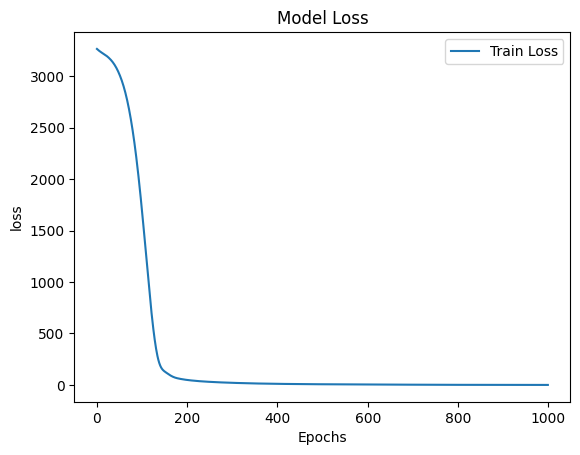

In [30]:
import matplotlib.pyplot as plt

print(history.history.keys())
plt.plot(history.history['loss'], label='Train Loss')
# model.fit에 validation_split이 업으면 val_loss, val_accuracy도 없음
# plt.plot(history.history['val_loss'], label='validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()


In [31]:
#평가

import tensorflow as tf
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'절대값 오차 평균 : {tf.sqrt(test_loss)}')
predictions = model.predict(np.array(X_test))

size = y_test.size 

for i in range(size):
  print(f'예측값 : {predictions[i][0]}, 실제값 : {y_test.values[i]}')
  pass

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.0000e+00 - loss: 375.5783
절대값 오차 평균 : 19.37984275817871
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
예측값 : 91.15129852294922, 실제값 : 90
예측값 : 53.026058197021484, 실제값 : 86
예측값 : 26.73002052307129, 실제값 : 14
예측값 : 41.86359405517578, 실제값 : 26


In [32]:
# 예측
# 집에서 5시간공부하고 결석 0
# 도서관에서 5시간 공부하고 결석 0
# 집에서 7시간 공부하고 결석 3
# 카페에서 6시간 공부하고 결석 2
# 원핫인코딩으로 X_test를 변환
new_dataset = [
	[5,0, 'Home'],
	[5,0, 'Library'],
	[7,3, 'Home'], 
	[7,0, 'Home'],
	[9,0, 'Home'],
]
# fit_transform : 학습 시키고 변환
# transform : 이전에 학습된 값을 기준으로 변환
new_dataset_encodng = ct.transform(new_dataset)
print(new_dataset_encodng)
predictions2 = model.predict(np.array(new_dataset_encodng, 'float32'))
for i in range(5):
	# 여러줄 쓰려고 + 붙여서 작성
	print(f'학습시간 : {new_dataset[i][0]}, ' 
			 + f'장소 : {new_dataset[i][2]}, '
			 + f'결석 :{new_dataset[i][1]}, ' 
			 + f'예측 성적 : {predictions2[i][0]}')

[[1.0 0.0 5 0]
 [0.0 1.0 5 0]
 [1.0 0.0 7 3]
 [1.0 0.0 7 0]
 [1.0 0.0 9 0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step

c:\Users\hi6\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
학습시간 : 5, 장소 : Home, 결석 :0, 예측 성적 : 38.151123046875
학습시간 : 5, 장소 : Library, 결석 :0, 예측 성적 : 56.195125579833984
학습시간 : 7, 장소 : Home, 결석 :3, 예측 성적 : 51.87042236328125
학습시간 : 7, 장소 : Home, 결석 :0, 예측 성적 : 44.366111755371094
학습시간 : 9, 장소 : Home, 결석 :0, 예측 성적 : 57.2589111328125
